# Building your own channels

The `HHChannel` class in MOOSE lets you define variations of Hodgkin-Huxley type ion channels. This can be done by specifying the equations for the gating dynamics.

## Start with passive compartment setup

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

import moose

# Import the channel model lib
import moose.channels as chan  


# Create a compartment called soma
soma = moose.Compartment('soma')

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


In [2]:
# Instrumentation for stimulation and recording

inject = moose.PulseGen('inject')
moose.connect(inject, 'output', soma, 'injectMsg')

inject_tab = moose.Table('inject_tab')
moose.connect(inject_tab, 'requestOut', inject, 'getOutputValue')

vm_tab = moose.Table('Vm_tab')
moose.connect(vm_tab, 'requestOut', soma, 'getVm')

<moose.SingleMsg path=/Msgs[0]/singleMsg[2] id=5 dataIndex=2 fieldIndex=0>

## Insert `HHChannel` into `Compartment`

As per the equivalent circuit below, we will create two channels: one Na channel and one K channel, following the original Hodgkin-Huxley model.

<img src="./images/HH_equivalent_circuit.png" alt="Equivalent circuit of a compartment with a K and an Na channel" width=300 />

In [3]:
nachan = moose.HHChannel('soma/Na')
kchan = moose.HHChannel('soma/K')

The channels must be connected to the compartment with `moose.connect()`

In [4]:
moose.connect(nachan, 'channel', soma, 'channel')
moose.connect(kchan, 'channel', soma, 'channel')

<moose.SingleMsg path=/Msgs[0]/singleMsg[4] id=5 dataIndex=4 fieldIndex=0>

## Specify the number of gates of each type in the Na channel
The Na channel has 4 gates 3 m-type gates and 1 h-type gate.

In Hodgkin and Huxley's formulation, the conductance of the channel at voltage V is given by

$G_{Na} = \bar{G}_{Na} \times m^{3} \times h$

where $m$ and $h$ are the voltage dependent probabilities of the gates being open.

The `HHChannel` class allows up to 3 gate types: `Xgate`, `Ygate`, and `Zgate`. Here we only need `X` gate for `m` and `Y` gate for `h`.

In [5]:
nachan.Xpower = 3   # m-gate , the power of m is 3 in the equation
nachan.Ypower = 1   # h-gate , the power of h is 1 in the equation

## Specifying the gate equations

Setting `HHChannel.Xpower` and `HHChannel.Ypower` to positive integers creates these gates. We can access them using `moose.element(path)` function. 

In [6]:
mgate = moose.element('soma/Na/gateX')
hgate = moose.element('soma/Na/gateY')

Now we can specify the equations for opening and closing rates of the gates. We use the equations from the original Hodgkin and Huxley (1952) model of the squid giant axon.

**A note on conventions.** Hodgkin and Huxley used a different convention for the membrane potential than we do now. Their $V$ was the *displacement* of the membrane potential from rest, so $V = 0$ at rest, and they took depolarization as *negative*. In modern convention we use the absolute membrane potential $u$ (inside relative to outside), with depolarization positive. With a resting potential of $-65$ mV the two are related by

$V_{HH} = -(u + 65)$

For example, Hodgkin and Huxley wrote the $m$-gate opening rate as

$\alpha_{m} = \frac{0.1 \times (V + 25)}{\exp{\left(\frac{V + 25}{10}\right)} - 1}$

Substituting $V = -(u + 65)$, in modern convention the opening and closing rates of the Na channel's `m` gates at a steady voltage $u$ become:

$\alpha_{m} = \frac{0.1 \times (u + 40)}{1 - \exp{\left(-\frac{u + 40}{10}\right)}}$

$\beta_{m} = 4 \times \exp{\left(-\frac{u + 65}{18}\right)}$

These equations assume the physiological unit system, where time is in milliseconds and voltage is in millivolts. We are using SI throughout, so the voltage must be multiplied by `1e3` and the rates must be multiplied by `1e3` as well.

In [7]:
mgate.alphaExpr = '1e3 * 0.1 * (v * 1e3 + 40) / (1 - exp(-(v * 1e3 + 40) / 10))'
mgate.betaExpr = '1e3 * 4 * exp(-(v * 1e3 + 65) / 18)'

Hodgkin and Huxley's equations for the `h` gate were

$\alpha_{h} = 0.07 \times \exp{\left(\frac{V}{20}\right)}$

$\beta_{h} = \frac{1}{\exp{\left(\frac{V + 30}{10}\right)} + 1}$

In modern convention these become

$\alpha_{h} = 0.07 \times \exp{\left(-\frac{u + 65}{20}\right)}$

$\beta_{h} = \frac{1}{1 + \exp{\left(-\frac{u + 35}{10}\right)}}$

Again, multiplying $u$ and the rates by `1e3` for unit conversion, we set

In [8]:
hgate.alphaExpr = '1e3 * 0.07 * exp(-(v * 1e3 + 65) / 20)'
hgate.betaExpr = '1e3 / (1 + exp(-(v * 1e3 + 35) / 10))'

The K channel has 4 `n` gates. Hodgkin and Huxley's equations were

$\alpha_{n} = \frac{0.01 \times (V + 10)}{\exp{\left(\frac{V + 10}{10}\right)} - 1}$

$\beta_{n} = 0.125 \times \exp{\left(\frac{V}{80}\right)}$

In modern convention these become

$\alpha_{n} = \frac{0.01 \times (u + 55)}{1 - \exp{\left(-\frac{u + 55}{10}\right)}}$

$\beta_{n} = 0.125 \times \exp{\left(-\frac{u + 65}{80}\right)}$

In [9]:
kchan.Xpower = 4
ngate = moose.element('soma/K/gateX')
ngate.alphaExpr = '1e3 * 0.01 * (v * 1e3 + 55) / (1 - exp(-(v * 1e3 + 55) / 10))'
ngate.betaExpr = '1e3 * 0.125 * exp(-(v * 1e3 + 65) / 80)'

### Configure interpolation table for the gates

For faster computation, `HHGate` objects create interpolation tables from the gate equations. We have to set the lower and upper bounds of the voltage and the number of divisions for these.

Note that $\alpha_m$ is $0/0$ at $u = -40$ mV and $\alpha_n$ is $0/0$ at $u = -55$ mV. The limits are finite, but evaluating the expression exactly at these points gives an invalid value. With 1000 divisions between -100 mV and 100 mV, both points fall on the table grid, so we use 999 divisions to step around them.

In [10]:
for gate in [mgate, hgate, ngate]:
    gate.divs = 999
    gate.max = 100e-3
    gate.min = -100e-3

## Set the passive properties of the compartment

In this example we will use specific (per unit area) values of the electrical properties, and scale them to a spherical soma of $10 \mu m$ radius.

In [11]:
area = 4 * np.pi * (10e-6)**2

The specific capacitance of the cell membrane is $0.01 F/m^{2}$

In [12]:
soma.Cm = 0.01 * area

The leak conductance, the inverse of membrane resistance, is $3 S/m^{2}$

In [13]:
soma.Rm = 1.0/(3 * area)

## Setting the maximum conductances of the channels

We will use the specific conductances of the channels from Hodgkin and Huxley:

Na: $120 mS/cm^{2} = 1200 S/m^{2}$.

K: $36 mS/cm^{2} = 360 S/m^{2}$

In [14]:
nachan.Gbar = 1200 * area
kchan.Gbar = 360 * area

## Set the ionic reversal potentials

The ionic concentration difference between the inside and the outside of the cell determines the driving force of the current passing through the channels. 

This is the reversal potential `Ek` of the channels. Hodgkin and Huxley's values relative to rest were $V_{Na} = -115$ mV and $V_{K} = +12$ mV. Converting with $u = -V_{HH} - 65$, we set `Ek = 50 mV` for Na and `Ek = -77 mV` for K.

In [15]:
nachan.Ek = 50e-3
kchan.Ek = -77e-3

The leak reversal potential in Hodgkin and Huxley's model was $V_{l} = -10.613$ mV, which is $u = -54.387$ mV in modern convention. This is the `Em` of the compartment. With it, the membrane rests at $-65$ mV, so we also start the simulation from there with `initVm`.

In [16]:
soma.Em = -54.387e-3
soma.initVm = -65e-3

### Set the experimental protocol

In [17]:
inject.delay[0] = 10e-3   # start the current pulse after 10 ms 
inject.width[0] = 50e-3   # the pulse width will be 50 ms
inject.level[0] = 0.2e-9   # pulse current amplitude will be 0.2 nA
inject.delay[1] = 1e9   # otherwise the pulse repeats every delay[0] + width[0]

## Initialize and run the simulation

In [18]:
moose.reinit()
moose.start(100e-3)

## Plot the membrane potential over time

Text(0.5, 0, 'Time (s)')

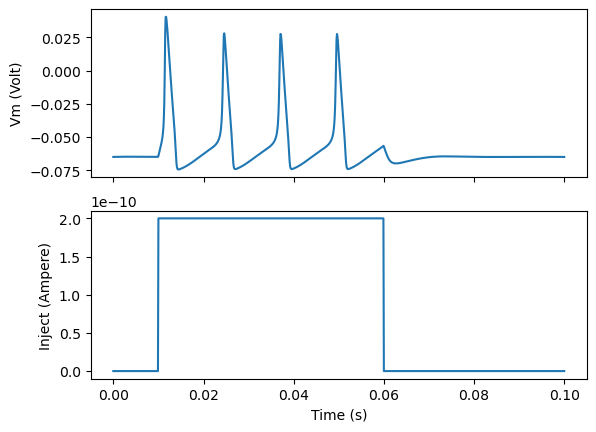

In [19]:
t = np.arange(len(vm_tab.vector)) * vm_tab.dt
fig, axes = plt.subplots(nrows=2, sharex='all')
axes[0].plot(t, vm_tab.vector)
axes[0].set_ylabel('Vm (Volt)')
axes[1].plot(t, inject_tab.vector)
axes[1].set_ylabel('Inject (Ampere)')
axes[1].set_xlabel('Time (s)')